<a href="https://colab.research.google.com/github/Kelly-Violet2/colab-week-3/blob/main/Week_3_parabola/myfile.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Standard imports for Week 3
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Display settings
pd.set_option('display.max_rows', None)
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 12

print("✅ Libraries loaded successfully!")
print(f"   NumPy version: {np.__version__}")

✅ Libraries loaded successfully!
   NumPy version: 2.0.2


In [2]:
def schaefer_growth(S, g, K):
    """Schaefer growth model: G(S) = g*S*(1 - S/K)"""
    return g * S * (1 - S/K)

# Parameters for fishery
g = 0.4    # Intrinsic growth rate
K = 1500  # Carrying capacity (tonnes)

# Calculate growth at various stock levels
S_values = np.array([0, 2000, 4000, 6000, 8000, 10000, 12000])
G_values = schaefer_growth(S_values, g, K)
rate_values = G_values / np.where(S_values > 0, S_values, 1) * 100  # Actual growth rate %

# Create DataFrame
df = pd.DataFrame({
    'Stock S (tonnes)': S_values,
    '1 - S/K': 1 - S_values/K,
    'Growth G(S) (tonnes/yr)': G_values,
    'Growth Rate (%)': np.where(S_values > 0, rate_values, g*100)
})

print("Schaefer Model: Growth at Different Stock Levels")
print("=" * 60)
print(df.to_string(index=False))
print(f"\n📌 Maximum growth of {max(G_values):.0f} tonnes/year occurs at S = {K/2:.0f} tonnes (K/2)")

Schaefer Model: Growth at Different Stock Levels
 Stock S (tonnes)   1 - S/K  Growth G(S) (tonnes/yr)  Growth Rate (%)
                0  1.000000                 0.000000        40.000000
             2000 -0.333333              -266.666667       -13.333333
             4000 -1.666667             -2666.666667       -66.666667
             6000 -3.000000             -7200.000000      -120.000000
             8000 -4.333333            -13866.666667      -173.333333
            10000 -5.666667            -22666.666667      -226.666667
            12000 -7.000000            -33600.000000      -280.000000

📌 Maximum growth of 0 tonnes/year occurs at S = 750 tonnes (K/2)


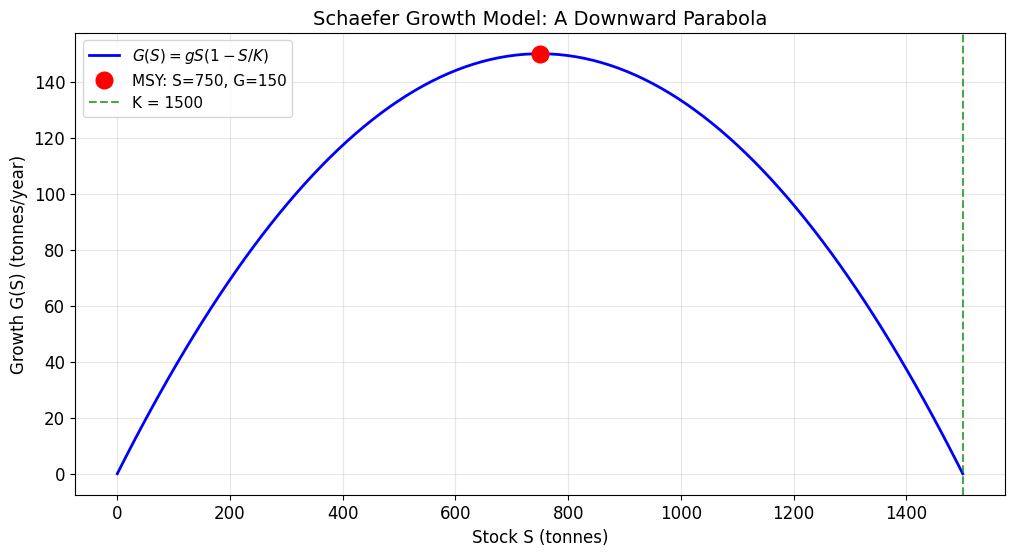

📌 Key Observations:
   - Growth is a quadratic function of stock (parabola)
   - Parabola opens downward (negative coefficient on S²)
   - Maximum at vertex: S = K/2 = 750 tonnes
   - MSY = gK/4 = 150 tonnes/year


In [3]:
# Visualize the Schaefer growth curve (parabola)
S = np.linspace(0, K, 200)
G = schaefer_growth(S, g, K)

plt.figure(figsize=(12, 6))
plt.plot(S, G, 'b-', linewidth=2, label=r'$G(S) = gS(1 - S/K)$')

# Mark MSY point
S_msy = K / 2
G_msy = schaefer_growth(S_msy, g, K)
plt.plot(S_msy, G_msy, 'ro', markersize=12, label=f'MSY: S={S_msy:.0f}, G={G_msy:.0f}')

# Mark K
plt.axvline(x=K, color='green', linestyle='--', alpha=0.7, label=f'K = {K}')

plt.xlabel('Stock S (tonnes)', fontsize=12)
plt.ylabel('Growth G(S) (tonnes/year)', fontsize=12)
plt.title('Schaefer Growth Model: A Downward Parabola', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

print("📌 Key Observations:")
print("   - Growth is a quadratic function of stock (parabola)")
print("   - Parabola opens downward (negative coefficient on S²)")
print(f"   - Maximum at vertex: S = K/2 = {S_msy:.0f} tonnes")
print(f"   - MSY = gK/4 = {g*K/4:.0f} tonnes/year")